In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm


In [2]:
import catboost as ctb
import lightgbm as lgb
import sklearn as sk
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier


In [3]:
from fit2082.boost.model import HashBoost

# from fit2082.demo.boost import NewHashBoost
from fit2082.quant.quant import Quant


In [4]:
import json
import subprocess
import time
from collections import defaultdict
from contextlib import contextmanager
from pathlib import Path

from IPython.display import display

from fit2082.demo.utils import Dataset


In [5]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
# global timings dict
timings: dict[str, list[dict[str, float]]] = defaultdict(list)

In [7]:
# timing util functions
@contextmanager
def timed(name: str, sync: bool = False):
    sync_ = sync and device == "cuda"
    if sync_:
        torch.cuda.synchronize()
    t0, c0 = time.perf_counter(), time.process_time()
    try:
        yield
    finally:
        if sync_:
            torch.cuda.synchronize()
        timings[name].append(
            {
                "wall_s": time.perf_counter() - t0,
                "cpu_s": time.process_time() - c0,
            }
        )

In [15]:
# plot helper
def plot_evals_result(title: str, res, err_label: str, xlabel="Round"):
    plt.title(label=title)
    plt.plot(res["tr"][err_label], label="train")
    plt.plot(res["va"][err_label], label="validation")
    plt.xlabel(xlabel)
    plt.ylabel(err_label)
    plt.legend()

In [17]:
np.random.seed(42)
torch.manual_seed(42)
# load data
path = "../data/"

dataset = "LenDB"

fn_X = f"{path}/{dataset}/{dataset}_X.npy"
fn_Y = f"{path}/{dataset}/{dataset}_y.npy"

data = Dataset(fn_X, fn_Y)

data.batch_size = 4_096

num_classes = np.int32(len(data.classes))

f0 = np.loadtxt(f"{path}/{dataset}/test_indices_fold_0.txt")

ix = np.setdiff1d(np.arange(data.shape[0]), f0)

n_tr = 32_768 * 2

n_va = 4_096
n_te = 4_096

np.random.shuffle(ix)

TR = ix[:n_tr]
VA = ix[n_tr : n_tr + n_va]
TE = ix[n_tr + n_va : n_tr + n_va + n_te]

data_TR = data[TR]
data_VA = data[VA]
data_TE = data[TE]

# Load in the full data
Xs, Ys = zip(*((X, Y) for X, Y in data_TR))
X_TR_raw = torch.tensor(np.concatenate(Xs).astype(np.float32), device=device)
Y_TR = torch.tensor(np.concatenate(Ys).astype(np.int32), device=device)

Xs, Ys = zip(*((X, Y) for X, Y in data_VA))
X_VA_raw = torch.tensor(np.concatenate(Xs).astype(np.float32), device=device)
Y_VA = torch.tensor(np.concatenate(Ys).astype(np.int32), device=device)

quant = Quant()
X_TR = quant.fit_transform(X_TR_raw, Y_TR)
X_VA = quant.transform(X_VA_raw)
# X_TR = X_TR_raw.squeeze()
# X_VA = X_VA_raw.squeeze()

# For simulating hashboost limited memory, so we only take 4096 samples
_size = 4096

X_TR_slice = X_TR[:_size]
X_VA_slice = X_VA[:_size]
Y_TR_slice = Y_TR[:_size]
Y_VA_slice = Y_VA[:_size]


data.close()

In [18]:
display(X_TR_raw.shape)
display(X_VA_raw.shape)
display(X_TR.shape)
display(Y_TR.shape)
display(X_TR_slice.shape)
display(Y_TR_slice.shape)

torch.Size([65536, 3, 540])

torch.Size([4096, 3, 540])

torch.Size([65536, 14940])

torch.Size([65536])

torch.Size([4096, 14940])

torch.Size([4096])

In [19]:
hb_params = {
    "num_classes": int(num_classes),
    "num_bits": 8,
    "lr": 0.1,
    "max_num_hashes": 1000,
    "hashes_per_round": 1,
    "max_epochs": 50,
}

# model = HashBoost(**{k: v for k, v in hb_params.items() if k not in ("max_epochs")})
model = HashBoost(
    num_classes=hb_params["num_classes"],
    num_bits=hb_params["num_bits"],
    lr=hb_params["lr"],
    max_num_hashes=hb_params["max_num_hashes"],
    hashes_per_round=hb_params["hashes_per_round"],
)
tr_record = []
va_record = []

count = 0

with timed("hashboost"):
    for i in tqdm(
        range(hb_params["max_epochs"]), total=hb_params["max_epochs"], ncols=80
    ):
        perm = torch.randperm(X_TR.shape[0], device=device)
        for s in range(0, X_TR.shape[0], _size):
            idxs = perm[s : s + _size]
            model.fit_batch(X_TR[idxs], Y_TR[idxs])
            count += 1

        tr_record.append(
            (
                count,
                (model.predict_proba(X_TR_slice).argmax(-1) != Y_TR_slice)
                .to(torch.float32)
                .mean()
                .item(),
            )
        )
        va_record.append(
            (
                count,
                (model.predict_proba(X_VA_slice).argmax(-1) != Y_VA_slice)
                .to(torch.float32)
                .mean()
                .item(),
            )
        )

hb_evals_result = {
    "tr": {"merror": pd.Series(dict(tr_record))},
    "va": {"merror": pd.Series(dict(va_record))},
}

# relevant_times = timings["hashboost_epoch"][-hb_params["max_epochs"] :]
# timings["hashboost"].append(
#     {
#         "wall_s": sum(stats["wall_s"] for stats in relevant_times),
#         "cpu_s": sum(stats["cpu_s"] for stats in relevant_times),
#     }
# )

print(f"count -> {count}; model.num_rounds -> {model.num_rounds}")

100%|███████████████████████████████████████████| 50/50 [02:15<00:00,  2.70s/it]

count -> 800; model.num_rounds -> 800


In [ ]:
# This model is the same as the above model, but will feature transform on-the-fly.
# So, this essentially simulates the scenario if we cannot fit all data in memory.
model = HashBoost(
    num_classes=hb_params["num_classes"],
    num_bits=hb_params["num_bits"],
    lr=hb_params["lr"],
    max_num_hashes=hb_params["max_num_hashes"],
    hashes_per_round=hb_params["hashes_per_round"],
)
tr_record = []
va_record = []

count = 0

with timed("hashboost"):
    for i in tqdm(
        range(hb_params["max_epochs"]), total=hb_params["max_epochs"], ncols=80
    ):
        for X, Y in data_TR:
            Xq = quant.transform(torch.tensor(X.astype(np.float32))).numpy()
            model.fit_batch(Xq, Y.astype(np.int32))

            count += 1

        tr_record.append(
            (
                count,
                (model.predict_proba(X_TR_slice).argmax(-1) != Y_TR_slice)
                .to(torch.float32)
                .mean()
                .item(),
            )
        )
        va_record.append(
            (
                count,
                (model.predict_proba(X_VA_slice).argmax(-1) != Y_VA_slice)
                .to(torch.float32)
                .mean()
                .item(),
            )
        )

hb_evals_result = {
    "tr": {"merror": pd.Series(dict(tr_record))},
    "va": {"merror": pd.Series(dict(va_record))},
}

print(f"count -> {count}; model.num_rounds -> {model.num_rounds}")

 30%|████████████▉                              | 15/50 [00:15<00:36,  1.06s/it]


KeyboardInterrupt: 

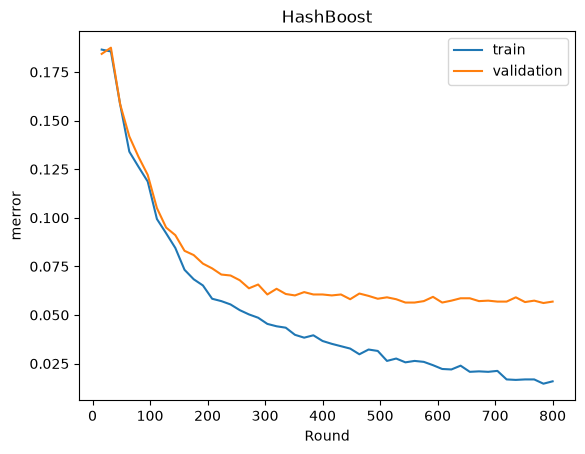

In [20]:
plot_evals_result("HashBoost", hb_evals_result, "merror")

In [21]:
# xgboost
# we can't use the wrapper because something funky with the data - data loaded only has 78 unique labels versus expected no. of 82.
# model_xgboost = xgb.XGBClassifier(
#     n_estimators=10,
#     device=device,
#     tree_method="hist",
#     objective="multi:softmax",
#     num_class=num_classes,
# )
dtrain = xgb.DMatrix(X_TR, label=Y_TR)
dvalid = xgb.DMatrix(X_VA, label=Y_VA)

xgb_params = {
    "objective": "multi:softprob",
    "num_class": int(num_classes),
    "tree_method": "hist",
    "device": device,
    "learning_rate": 0.05,
    "max_depth": 6,
    "random_state": 42,
    "eval_metric": "merror",
    "num_boost_round": 1000,
    "early_stopping_rounds": 50,
}

xgb_evals_result = {}

with timed("xgboost", sync=True):
    xgb_bst = xgb.train(
        {
            k: v
            for k, v in xgb_params.items()
            if k not in ("num_boost_round", "early_stopping_rounds")
        },
        dtrain,
        early_stopping_rounds=xgb_params["early_stopping_rounds"],
        num_boost_round=xgb_params["num_boost_round"],
        evals=[(dtrain, "tr"), (dvalid, "va")],
        evals_result=xgb_evals_result,
        verbose_eval=False,
    )


XGBoostError: [13:41:12] /__w/xgboost/xgboost/src/common/device_vector.cu:53: Memory allocation error on worker 0: std::bad_alloc: cudaErrorMemoryAllocation: out of memory
- Free memory: 0B
- Requested memory: 7.29492GB
- Reserved by the pool: 0B
- Used by the pool: 0B

Stack trace:
  [bt] (0) /home/matt/Documents/uni/y2/s2/fit2082/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0x21ec5c) [0x7887f521ec5c]
  [bt] (1) /home/matt/Documents/uni/y2/s2/fit2082/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0xaaf3a6) [0x7887f5aaf3a6]
  [bt] (2) /home/matt/Documents/uni/y2/s2/fit2082/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0xb16721) [0x7887f5b16721]
  [bt] (3) /home/matt/Documents/uni/y2/s2/fit2082/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0xd72d18) [0x7887f5d72d18]
  [bt] (4) /home/matt/Documents/uni/y2/s2/fit2082/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.so(+0xd746b0) [0x7887f5d746b0]
  [bt] (5) /home/matt

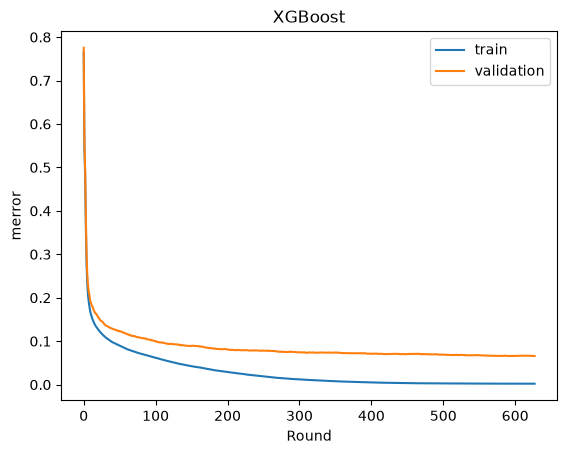

In [40]:
plot_evals_result("XGBoost", xgb_evals_result, "merror")

In [ ]:
# lightgbm
# lgb.Dataset only takes host arrays (numpy/pandas/scipy/pyarrow), so unlike
# xgb.DMatrix it can't read a cuda tensor - move to cpu and hand it numpy.
X_TR_np = X_TR.detach().cpu().numpy()
X_VA_np = X_VA.detach().cpu().numpy()
Y_TR_np = Y_TR.detach().cpu().numpy()
Y_VA_np = Y_VA.detach().cpu().numpy()

lgb_params = {
    "objective": "multiclass",
    "num_class": int(num_classes),
    "metric": "multi_error",
    "num_leaves": 31,
    "max_depth": -1,
    "learning_rate": 0.05,
    "random_state": 42,
    "verbosity": -1,
    "num_boost_round": 1000,
    "early_stopping_rounds": 50,
}

_p = {
    k: v
    for k, v in lgb_params.items()
    if k not in ("num_boost_round", "early_stopping_rounds")
}

dtrain = lgb.Dataset(X_TR_np, label=Y_TR_np, params=_p)
dvalid = lgb.Dataset(X_VA_np, label=Y_VA_np, params=_p)

lgb_evals_result = {}

with timed("lightgbm", sync=True):
    lgb_bst = lgb.train(
        _p,
        dtrain,
        num_boost_round=lgb_params["num_boost_round"],
        valid_sets=[dtrain, dvalid],
        valid_names=["tr", "va"],
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=lgb_params["early_stopping_rounds"], verbose=False
            ),
            lgb.record_evaluation(lgb_evals_result),
            lgb.log_evaluation(0),
        ],
    )

for v in lgb_evals_result.values():
    v["merror"] = v.pop("multi_error")

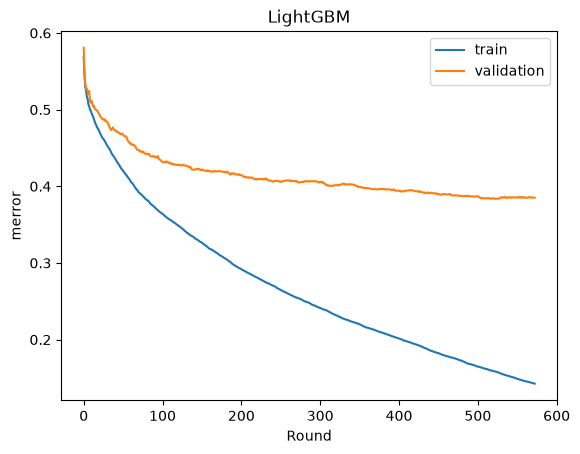

In [ ]:
plot_evals_result("LightGBM", lgb_evals_result, "merror")

In [ ]:
# catboost
tr_pool = ctb.Pool(X_TR_np, Y_TR_np)
va_pool = ctb.Pool(X_VA_np, Y_VA_np)

ctb_params = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "loss_function": "MultiClass",
    "classes_count": int(num_classes),
    "eval_metric": "Accuracy",
    "depth": 6,
    "early_stopping_rounds": 50,
    "random_state": 42,
    "task_type": "GPU" if device == "cuda" else "CPU",
    "verbose": 0,
}

ctb_model = ctb.CatBoostClassifier(**ctb_params)

with timed("catboost", sync=True):
    ctb_model.fit(tr_pool, eval_set=va_pool)

ctb_evals_result = ctb_model.get_evals_result()
ctb_evals_result = {
    "tr": {"merror": [1 - acc for acc in ctb_evals_result["learn"]["Accuracy"]]},
    "va": {"merror": [1 - acc for acc in ctb_evals_result["validation"]["Accuracy"]]},
}

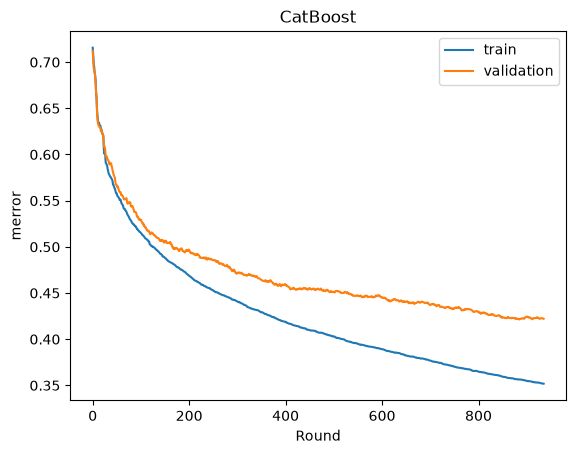

In [ ]:
plot_evals_result("CatBoost", ctb_evals_result, "merror")

In [ ]:
# sklearn decision tree
# we plot depth -> error

tree_params = {"depths": [32], "random_state": 42}

tree_eval_results = defaultdict(lambda: defaultdict(lambda: pd.Series()))
for depth in tree_params["depths"]:
    tree = DecisionTreeClassifier(
        max_depth=depth, random_state=tree_params["random_state"]
    )
    with timed(f"tree_d{depth}"):
        tree.fit(X_TR_np, Y_TR_np)
    tree_eval_results["tr"]["merror"][depth] = (tree.predict(X_TR_np) != Y_TR_np).mean()
    tree_eval_results["va"]["merror"][depth] = (tree.predict(X_VA_np) != Y_VA_np).mean()

for k in tree_eval_results:
    tree_eval_results[k]["merror"] = pd.Series(tree_eval_results[k]["merror"])

defaultdict(<function __main__.<lambda>()>,
            {'tr': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'merror': 32    0.00119
                          dtype: float64}),
             'va': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'merror': 32    0.514404
                          dtype: float64})})

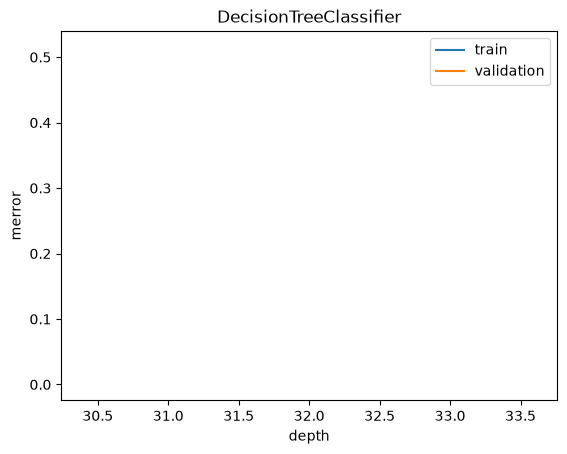

In [ ]:
plot_evals_result("DecisionTreeClassifier", tree_eval_results, "merror", "depth")
tree_eval_results

In [22]:
# write results to disk
def get_current_git_hash(short: bool = True) -> str | None:
    try:
        command = ["git", "rev-parse", "HEAD"]
        if short:
            command.insert(2, "--short")

        # Execute command and decode bytes to a string
        commit_hash = subprocess.check_output(command, stderr=subprocess.DEVNULL)
        return commit_hash.decode("utf-8").strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


def _json_default(o):
    if isinstance(o, np.generic):
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


def _curve(values):
    s = pd.Series(values)
    return {"x": s.index.tolist(), "y": s.tolist()}


def write_results(path: str, models: dict[str, tuple], **info):
    """write model params + eval curves to a single json

    path   : file to write, e.g. "../results/Pedestrian.json"
    models : {name: (params, evals_result, x_name)}
    info   : any run level info to record alongside (dataset, device, split, ...)
    """
    info["models"] = {
        name: {
            "x_name": x_name,
            "params": params,
            "timings": timings.get(name),
            "results": {
                split: {metric: _curve(values) for metric, values in metrics.items()}
                for split, metrics in evals.items()
            },
        }
        for name, (params, evals, x_name) in models.items()
    }

    path_ = Path(path)
    path_.parent.mkdir(parents=True, exist_ok=True)
    path_.write_text(json.dumps(info, indent=2, default=_json_default))

    return path_

In [23]:
_ = write_results(
    f"../results/{dataset}-{get_current_git_hash()}.json",
    {
        "hashboost": (hb_params, hb_evals_result, "batch"),
        # "xgboost": (xgb_params, xgb_evals_result, "round"),
        # "lightgbm": (lgb_params, lgb_evals_result, "round"),
        # "catboost": (ctb_params, ctb_evals_result, "round"),
        # "tree": (tree_params, tree_eval_results, "depth"),
    },
    commit=get_current_git_hash(),
    dataset=dataset,
    device=device,
    split={
        "fold": 0,
        "seed": 42,
        "n_tr": n_tr,
        "n_va": n_va,
        "n_te": n_te,
        "n_eval_subsample": _size,
        "batch_size": data.batch_size,
        "num_classes": num_classes,
    },
    transform={
        "name": "quant",
        "depth": quant.depth,
        "div": quant.div,
        "num_features": X_TR.shape[1]
    }
)